## Regressão Linear

A regressão linear é um método estatístico que modela a relação entre uma variável dependente $y$ e uma ou mais variáveis independentes $x$, assumindo que essa relação é **linear**.

### Modelo

Para o caso simples (uma variável preditora), o modelo é:

$$\hat{y} = \beta_0 + \beta_1 x$$

Onde:
- $\hat{y}$ — valor predito
- $\beta_0$ — intercepto (valor de $y$ quando $x = 0$)
- $\beta_1$ — coeficiente angular (inclinação da reta)

### Estimação dos parâmetros

Os coeficientes $\beta_0$ e $\beta_1$ são estimados pelo método dos **Mínimos Quadrados Ordinários (MQO)**, que minimiza a soma dos erros quadráticos (SSE):

$$\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

As fórmulas fechadas para os coeficientes são:

$$\beta_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} \qquad \beta_0 = \bar{y} - \beta_1 \bar{x}$$

### Avaliação do modelo

A qualidade do ajuste é medida pelo coeficiente de determinação $R^2 \in [0, 1]$:

$$R^2 = 1 - \frac{\text{SSE}}{\text{SST}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

Um $R^2$ próximo de 1 indica que o modelo explica bem a variância dos dados.

### Premissas principais

1. **Linearidade** — relação linear entre $x$ e $y$  
2. **Homocedasticidade** — variância constante dos resíduos  
3. **Independência** — observações independentes entre si  
4. **Normalidade** — resíduos com distribuição normal (para inferência)

# Atividade 1 

## Visualizando o efeito dos parâmetros $a$ e $b$

Para $y = f(x) = a \cdot x + b$, investigamos visualmente:

- **Coeficiente angular $a$**: controla a **inclinação** da reta
  - $a < 0$ → reta decrescente
  - $a = 0$ → reta horizontal
  - $a > 0$ → reta crescente

- **Intercepto $b$**: controla onde a reta **cruza o eixo $y$**
  - $b < 0$ → reta abaixo da origem
  - $b = 0$ → reta passa pela origem
  - $b > 0$ → reta acima da origem

<>:48: SyntaxWarning: invalid escape sequence '\c'
<>:48: SyntaxWarning: invalid escape sequence '\c'
C:\Users\gnose\AppData\Local\Temp\ipykernel_17352\4255222129.py:48: SyntaxWarning: invalid escape sequence '\c'
  plt.suptitle('Regressão Linear: $y = a \cdot x + b$', fontsize=14, fontweight='bold', y=1.02)


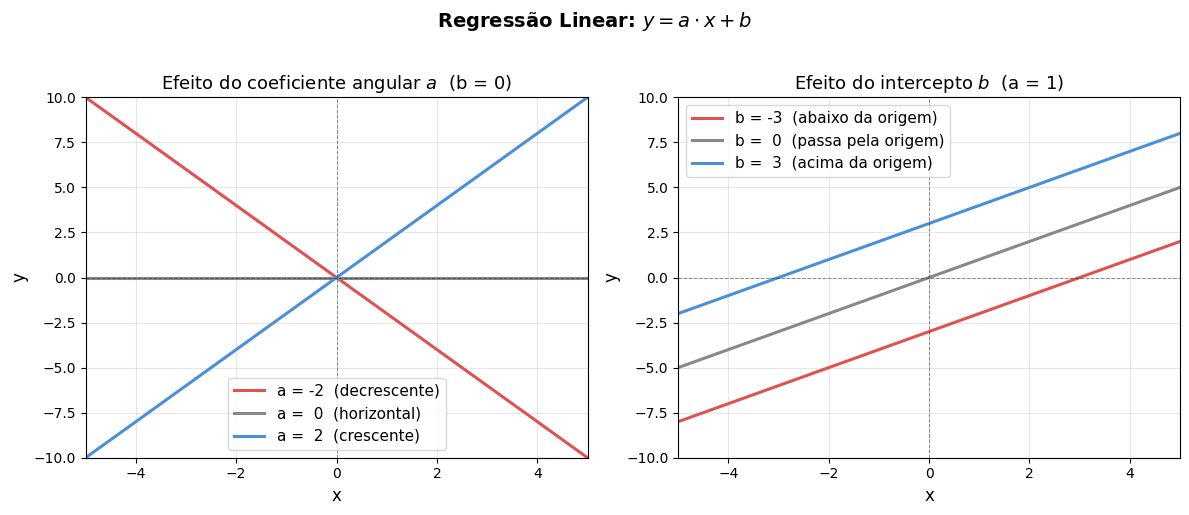

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfico 1: variando a (b = 0 fixo) ---
configs_a = [
    (-2, 'a = -2  (decrescente)', '#e05252'),
    ( 0, 'a =  0  (horizontal)',  '#888888'),
    ( 2, 'a =  2  (crescente)',   '#4a90d9'),
]

for a, label, color in configs_a:
    ax1.plot(x, a * x, label=label, color=color, linewidth=2.2)

ax1.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
ax1.axvline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
ax1.set_xlim(-5, 5)
ax1.set_ylim(-10, 10)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Efeito do coeficiente angular $a$  (b = 0)', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- Gráfico 2: variando b (a = 1 fixo) ---
configs_b = [
    (-3, 'b = -3  (abaixo da origem)', '#e05252'),
    ( 0, 'b =  0  (passa pela origem)', '#888888'),
    ( 3, 'b =  3  (acima da origem)',   '#4a90d9'),
]

for b, label, color in configs_b:
    ax2.plot(x, x + b, label=label, color=color, linewidth=2.2)

ax2.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
ax2.axvline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
ax2.set_xlim(-5, 5)
ax2.set_ylim(-10, 10)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title('Efeito do intercepto $b$  (a = 1)', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('Regressão Linear: $y = a \cdot x + b$', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Atividade 2

## Estimando os parâmetros $a$ e $b$ a partir de dados

Dado um conjunto de observações $(x_i, y_i)$, queremos encontrar $a$ e $b$ que melhor
ajustam a reta $\hat{y} = ax + b$ aos dados.

Pelo método dos **Mínimos Quadrados Ordinários (MQO)**, minimizamos o erro total:

$$SSE = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 = \sum_{i=1}^{n}(y_i - ax_i - b)^2$$

A solução analítica é:

$$a = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2} \qquad b = \bar{y} - a\bar{x}$$



=== MQO — implementação manual ===
  a estimado  : 2.3825  |  a verdadeiro : 2.5
  b estimado  : -2.9342  |  b verdadeiro : -3.0
  R²          : 0.9593


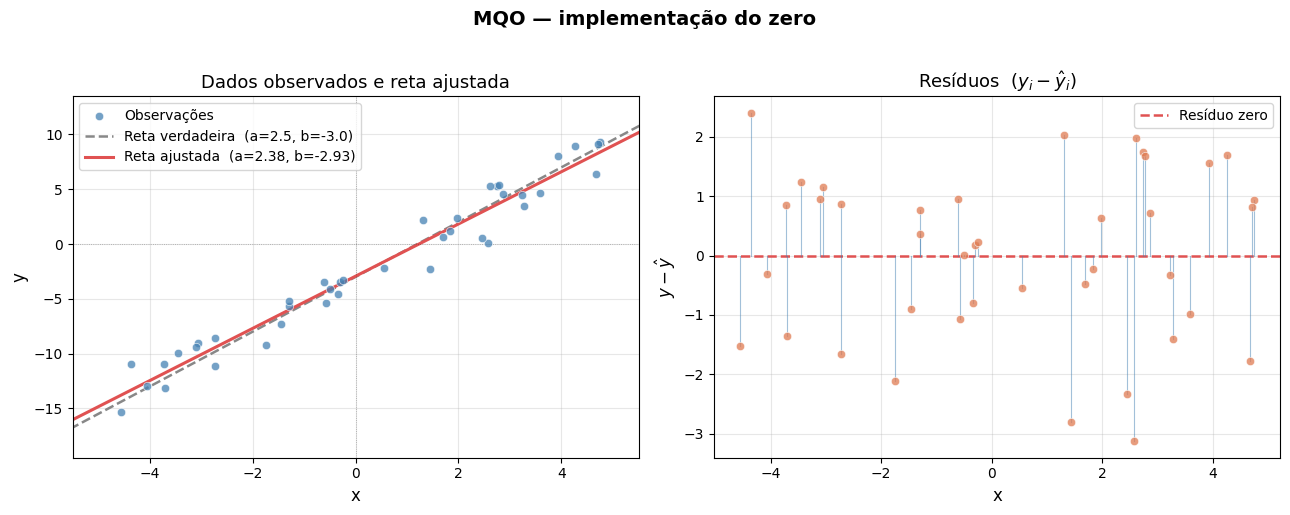

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ── Dados simulados ───────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

a_true, b_true = 2.5, -3.0
x = rng.uniform(-5, 5, size=40)
y = a_true * x + b_true + rng.normal(0, 2.0, size=40)

# ── Implementação MQO do zero ─────────────────────────────────────────────────
def mqo(x, y):
    n     = len(x)
    x_bar = sum(x) / n
    y_bar = sum(y) / n

    num = sum((x[i] - x_bar) * (y[i] - y_bar) for i in range(n))
    den = sum((x[i] - x_bar) ** 2               for i in range(n))

    a = num / den
    b = y_bar - a * x_bar
    return a, b

def r_squared(x, y, a, b):
    y_bar = sum(y) / len(y)
    ss_res = sum((y[i] - (a * x[i] + b)) ** 2 for i in range(len(y)))
    ss_tot = sum((y[i] - y_bar)           ** 2 for i in range(len(y)))
    return 1 - ss_res / ss_tot

def predict(x, a, b):
    return [a * xi + b for xi in x]

# ── Estimativa ────────────────────────────────────────────────────────────────
a_hat, b_hat = mqo(x, y)
r2           = r_squared(x, y, a_hat, b_hat)

print("=== MQO — implementação manual ===")
print(f"  a estimado  : {a_hat:.4f}  |  a verdadeiro : {a_true}")
print(f"  b estimado  : {b_hat:.4f}  |  b verdadeiro : {b_true}")
print(f"  R²          : {r2:.4f}")

# ── Visualização ──────────────────────────────────────────────────────────────
x_line  = list(range(-60, 61))               # -6.0 a 6.0 em passos de 0.1
x_line  = [v / 10 for v in x_line]
y_true  = [a_true * xi + b_true for xi in x_line]
y_fit   = [a_hat  * xi + b_hat  for xi in x_line]
y_pred  = predict(x, a_hat, b_hat)
resid   = [y[i] - y_pred[i] for i in range(len(y))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1 — observações + retas
ax = axes[0]
ax.scatter(x, y, color='steelblue', alpha=0.75, edgecolors='white',
           linewidth=0.5, zorder=3, label='Observações')
ax.plot(x_line, y_true, color='#888888', linewidth=1.8,
        linestyle='--', label=f'Reta verdadeira  (a={a_true}, b={b_true})')
ax.plot(x_line, y_fit,  color='#e05252', linewidth=2.2,
        label=f'Reta ajustada  (a={a_hat:.2f}, b={b_hat:.2f})')

ax.axhline(0, color='black', linewidth=0.6, linestyle=':', alpha=0.3)
ax.axvline(0, color='black', linewidth=0.6, linestyle=':', alpha=0.3)
ax.set_xlim(-5.5, 5.5)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Dados observados e reta ajustada', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Gráfico 2 — resíduos
ax = axes[1]
ax.scatter(x, resid, color='#e07b52', alpha=0.75,
           edgecolors='white', linewidth=0.5, zorder=3)
ax.axhline(0, color='#e05252', linewidth=1.8, linestyle='--', label='Resíduo zero')

for xi, ri in zip(x, resid):
    ax.plot([xi, xi], [0, ri], color='steelblue', linewidth=0.8, alpha=0.5)

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('$y - \\hat{y}$', fontsize=12)
ax.set_title('Resíduos  $(y_i - \\hat{y}_i)$', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('MQO — implementação do zero', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##  Atividade 3 Busca exaustiva dos parâmetros $a$ e $b$

Em vez de usar a solução analítica, vamos **varrer um grid de valores** de $a$ e $b$
e avaliar cada combinação com uma função objetiva.

A função objetiva mede o **erro total** de uma reta candidata. Testamos três versões:

---

### 1. Diferença simples (soma dos erros)

$$f_1(a,b) = \sum_{i=1}^{n}(y_i - \hat{y}_i)$$

**Problema:** erros positivos e negativos se cancelam.
Uma reta péssima pode ter $f_1 = 0$ se os erros se anularem mutuamente.
**Não serve como função objetiva.**

---

### 2. Valor absoluto da diferença (MAE)

$$f_2(a,b) = \sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**Vantagem:** erros não se cancelam — todo desvio contribui positivamente.
**Desvantagem:** não é diferenciável em zero (canto), o que dificulta
otimização analítica. Mas funciona bem para busca exaustiva.
Trata erros grandes e pequenos de forma **proporcional**.

---

### 3. Diferença quadrática (SSE)

$$f_3(a,b) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**Vantagem:** diferenciável em todo ponto (permite solução analítica).
Penaliza erros grandes **de forma desproporcional** — um erro de 2
vale 4 vezes mais que um erro de 1. Isso força a reta a evitar
desvios grandes, sendo mais sensível a outliers.
**É o critério do MQO.**

---

### Por que isso importa?

| Função       | Cancela erros? | Sensível a outliers | Diferenciável |
|--------------|:--------------:|:-------------------:|:-------------:|
| Diferença    | Sim — inútil   | —                   | Sim           |
| Abs (MAE)    | Não            | Menos               | Não em zero   |
| Quadrática   | Não            | Mais                | Sim           |

A escolha da função objetiva **muda qual reta é considerada ótima.**

=== Busca exaustiva ===

MAE  → a=0.50, b=1.50  | erro=2.0000
SSE  → a=0.50, b=1.25  | erro=2.2500

MQO analítico → a=0.50, b=1.25


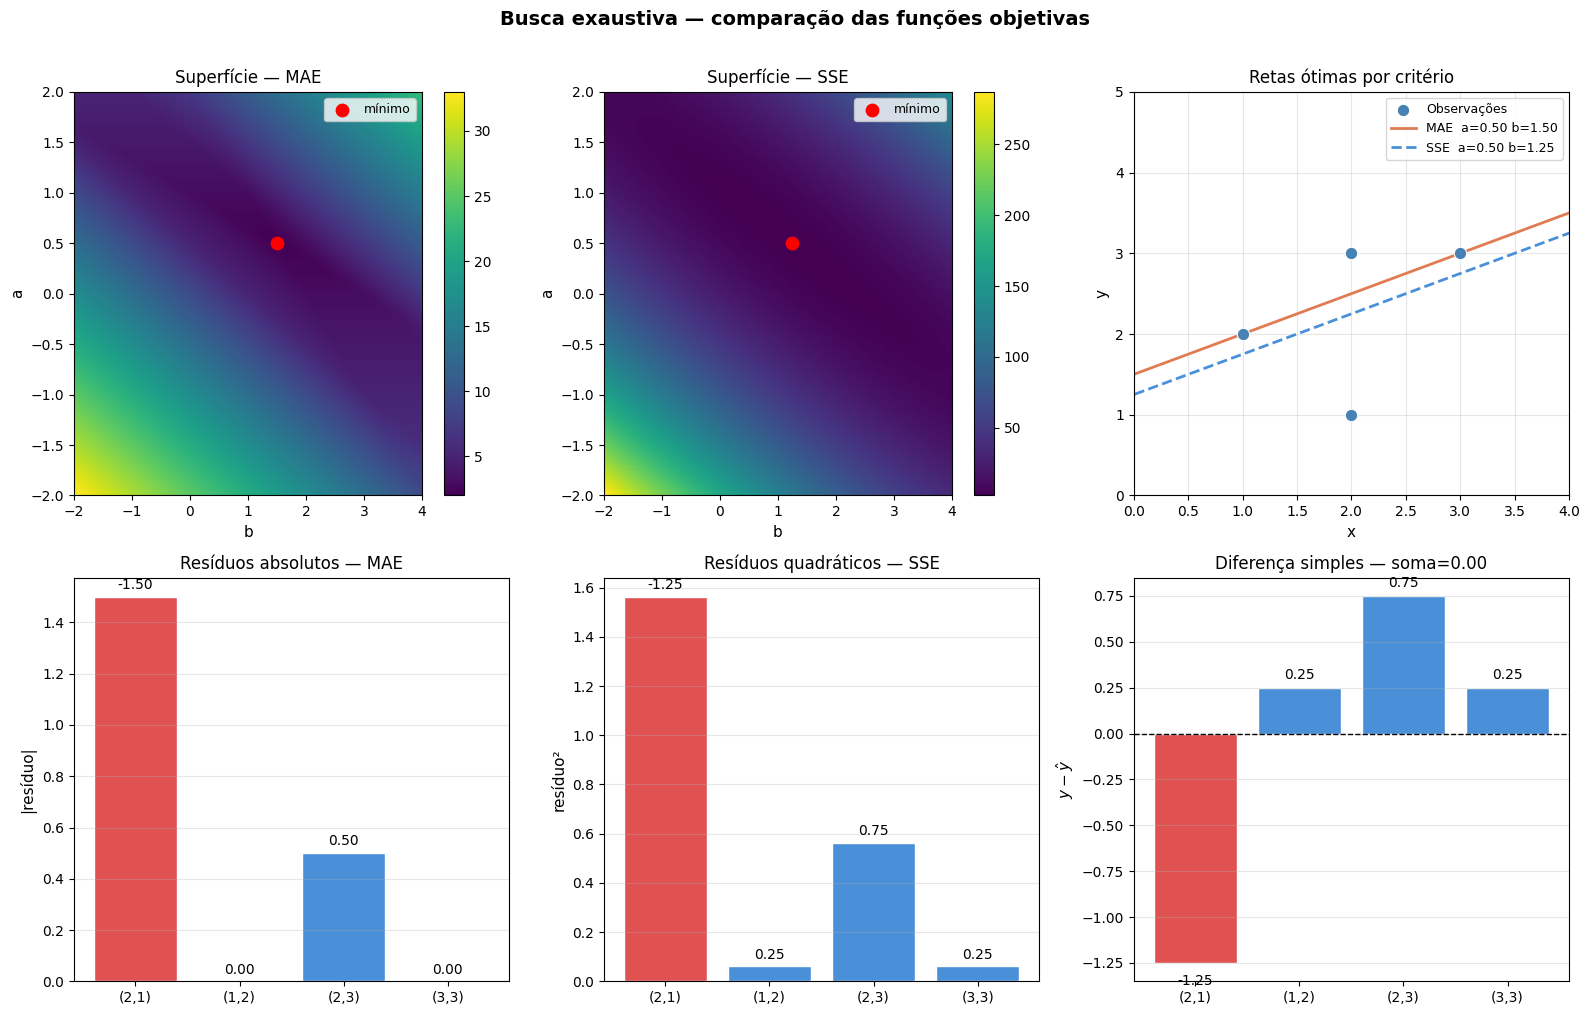

In [7]:


# ── Dados ─────────────────────────────────────────────────────────────────────
x = [2, 1, 2, 3]
y = [1, 2, 3, 3]

# ── Funções objetivas ─────────────────────────────────────────────────────────
def erro_simples(x, y, a, b):
    return sum((y[i] - (a * x[i] + b)) for i in range(len(x)))

def erro_absoluto(x, y, a, b):
    return sum(abs(y[i] - (a * x[i] + b)) for i in range(len(x)))

def erro_quadratico(x, y, a, b):
    return sum((y[i] - (a * x[i] + b)) ** 2 for i in range(len(x)))

# ── Busca exaustiva ───────────────────────────────────────────────────────────
passo    = 0.05
valores_a = [round(-2 + i * passo, 4) for i in range(int(4 / passo) + 1)]
valores_b = [round(-2 + i * passo, 4) for i in range(int(6 / passo) + 1)]

melhor_abs  = {'a': None, 'b': None, 'erro': float('inf')}
melhor_sqe  = {'a': None, 'b': None, 'erro': float('inf')}

grid_abs = []
grid_sqe = []

for a in valores_a:
    linha_abs, linha_sqe = [], []
    for b in valores_b:
        e_abs = erro_absoluto(x, y, a, b)
        e_sqe = erro_quadratico(x, y, a, b)
        linha_abs.append(e_abs)
        linha_sqe.append(e_sqe)

        if e_abs < melhor_abs['erro']:
            melhor_abs = {'a': a, 'b': b, 'erro': e_abs}
        if e_sqe < melhor_sqe['erro']:
            melhor_sqe = {'a': a, 'b': b, 'erro': e_sqe}

    grid_abs.append(linha_abs)
    grid_sqe.append(linha_sqe)

print("=== Busca exaustiva ===")
print(f"\nMAE  → a={melhor_abs['a']:.2f}, b={melhor_abs['b']:.2f}  | erro={melhor_abs['erro']:.4f}")
print(f"SSE  → a={melhor_sqe['a']:.2f}, b={melhor_sqe['b']:.2f}  | erro={melhor_sqe['erro']:.4f}")
print(f"\nMQO analítico → a=0.50, b=1.25")

# ── Visualização ──────────────────────────────────────────────────────────────
x_line = [v / 10 for v in range(-5, 45)]

fig = plt.figure(figsize=(16, 10))

# --- superfície MAE ---
ax1 = fig.add_subplot(2, 3, 1)
img1 = ax1.imshow(
    grid_abs, origin='lower', aspect='auto',
    extent=[min(valores_b), max(valores_b), min(valores_a), max(valores_a)],
    cmap='viridis'
)
ax1.scatter(melhor_abs['b'], melhor_abs['a'], color='red', s=80, zorder=5, label='mínimo')
ax1.set_xlabel('b', fontsize=11)
ax1.set_ylabel('a', fontsize=11)
ax1.set_title('Superfície — MAE', fontsize=12)
ax1.legend(fontsize=9)
plt.colorbar(img1, ax=ax1)

# --- superfície SSE ---
ax2 = fig.add_subplot(2, 3, 2)
img2 = ax2.imshow(
    grid_sqe, origin='lower', aspect='auto',
    extent=[min(valores_b), max(valores_b), min(valores_a), max(valores_a)],
    cmap='viridis'
)
ax2.scatter(melhor_sqe['b'], melhor_sqe['a'], color='red', s=80, zorder=5, label='mínimo')
ax2.set_xlabel('b', fontsize=11)
ax2.set_ylabel('a', fontsize=11)
ax2.set_title('Superfície — SSE', fontsize=12)
ax2.legend(fontsize=9)
plt.colorbar(img2, ax=ax2)

# --- comparação das retas ---
ax3 = fig.add_subplot(2, 3, 3)
ax3.scatter(x, y, color='steelblue', s=80, zorder=4,
            edgecolors='white', linewidth=0.8, label='Observações')
ax3.plot(x_line, [melhor_abs['a'] * xi + melhor_abs['b'] for xi in x_line],
         color='#e07b52', linewidth=2, label=f"MAE  a={melhor_abs['a']:.2f} b={melhor_abs['b']:.2f}")
ax3.plot(x_line, [melhor_sqe['a'] * xi + melhor_sqe['b'] for xi in x_line],
         color='#4a90d9', linewidth=2, linestyle='--', label=f"SSE  a={melhor_sqe['a']:.2f} b={melhor_sqe['b']:.2f}")
ax3.set_xlim(0, 4)
ax3.set_ylim(0, 5)
ax3.set_xlabel('x', fontsize=11)
ax3.set_ylabel('y', fontsize=11)
ax3.set_title('Retas ótimas por critério', fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# --- erro por ponto: MAE ---
ax4 = fig.add_subplot(2, 3, 4)
y_pred_abs = [melhor_abs['a'] * xi + melhor_abs['b'] for xi in x]
resid_abs  = [y[i] - y_pred_abs[i] for i in range(len(y))]
labels     = [f'({x[i]},{y[i]})' for i in range(len(x))]
cores      = ['#e05252' if r < 0 else '#4a90d9' for r in resid_abs]
ax4.bar(labels, [abs(r) for r in resid_abs], color=cores, edgecolor='white')
for i, r in enumerate(resid_abs):
    ax4.text(i, abs(r) + 0.03, f'{r:.2f}', ha='center', fontsize=10)
ax4.set_ylabel('|resíduo|', fontsize=11)
ax4.set_title('Resíduos absolutos — MAE', fontsize=12)
ax4.grid(True, alpha=0.3, axis='y')

# --- erro por ponto: SSE ---
ax5 = fig.add_subplot(2, 3, 5)
y_pred_sqe = [melhor_sqe['a'] * xi + melhor_sqe['b'] for xi in x]
resid_sqe  = [y[i] - y_pred_sqe[i] for i in range(len(y))]
cores      = ['#e05252' if r < 0 else '#4a90d9' for r in resid_sqe]
ax5.bar(labels, [r**2 for r in resid_sqe], color=cores, edgecolor='white')
for i, r in enumerate(resid_sqe):
    ax5.text(i, r**2 + 0.03, f'{r:.2f}', ha='center', fontsize=10)
ax5.set_ylabel('resíduo²', fontsize=11)
ax5.set_title('Resíduos quadráticos — SSE', fontsize=12)
ax5.grid(True, alpha=0.3, axis='y')

# --- diferença simples: demonstração do cancelamento ---
ax6 = fig.add_subplot(2, 3, 6)
a_demo, b_demo = 0.5, 1.25
y_pred_demo = [a_demo * xi + b_demo for xi in x]
resid_demo  = [y[i] - y_pred_demo[i] for i in range(len(y))]
cores       = ['#e05252' if r < 0 else '#4a90d9' for r in resid_demo]
ax6.bar(labels, resid_demo, color=cores, edgecolor='white')
for i, r in enumerate(resid_demo):
    ax6.text(i, r + (0.05 if r >= 0 else -0.12), f'{r:.2f}', ha='center', fontsize=10)
ax6.axhline(0, color='black', linewidth=1, linestyle='--')
ax6.set_ylabel('$y - \\hat{y}$', fontsize=11)
ax6.set_title(f'Diferença simples — soma={sum(resid_demo):.2f}', fontsize=12)
ax6.grid(True, alpha=0.3, axis='y')

plt.suptitle('Busca exaustiva — comparação das funções objetivas', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Atividade 4 Solução analítica da regressão linear

O objetivo é encontrar $a$ e $b$ que minimizem o erro total entre os valores
observados $y_i$ e os valores preditos $\hat{y}_i = ax_i + b$.

---

## 1. Função objetiva

Usamos a soma dos erros quadráticos (SSE):

$$SSE(a, b) = \sum_{i=1}^{n}(y_i - ax_i - b)^2$$

Queremos:

$$\min_{a,\, b} \;\; SSE(a, b)$$

---

## 2. Por que derivar?

$SSE(a, b)$ é uma superfície convexa (paraboloide) no espaço de $a$ e $b$.
O mínimo de uma função convexa ocorre onde **todas as derivadas parciais são zero** —
ou seja, onde nenhuma pequena perturbação em $a$ ou $b$ consegue reduzir o erro.

$$\frac{\partial SSE}{\partial a} = 0 \qquad \frac{\partial SSE}{\partial b} = 0$$

---

## 3. Derivando em relação a $b$

$$\frac{\partial SSE}{\partial b} = \sum_{i=1}^{n} 2(y_i - ax_i - b)(-1) = 0$$

Dividindo por $-2$:

$$\sum_{i=1}^{n}(y_i - ax_i - b) = 0$$

Expandindo a soma:

$$\sum y_i - a\sum x_i - nb = 0$$

Isolando $b$:

$$b = \frac{\sum y_i - a \sum x_i}{n} = \bar{y} - a\bar{x}$$

> **Interpretação:** a reta ótima sempre passa pelo ponto médio $(\bar{x}, \bar{y})$
> dos dados, independente de $a$.

---

## 4. Derivando em relação a $a$

$$\frac{\partial SSE}{\partial a} = \sum_{i=1}^{n} 2(y_i - ax_i - b)(-x_i) = 0$$

Dividindo por $-2$:

$$\sum_{i=1}^{n} x_i(y_i - ax_i - b) = 0$$

Substituindo $b = \bar{y} - a\bar{x}$:

$$\sum_{i=1}^{n} x_i\bigl(y_i - ax_i - (\bar{y} - a\bar{x})\bigr) = 0$$

$$\sum_{i=1}^{n} x_i\bigl((y_i - \bar{y}) - a(x_i - \bar{x})\bigr) = 0$$

Expandindo:

$$\sum_{i=1}^{n} x_i(y_i - \bar{y}) - a\sum_{i=1}^{n} x_i(x_i - \bar{x}) = 0$$

Usando a identidade $\sum x_i(x_i - \bar{x}) = \sum (x_i - \bar{x})^2$
e $\sum x_i(y_i - \bar{y}) = \sum (x_i - \bar{x})(y_i - \bar{y})$:

$$\sum(x_i - \bar{x})(y_i - \bar{y}) = a \sum(x_i - \bar{x})^2$$

Isolando $a$:

$$a = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

> **Interpretação:** $a$ é a razão entre a **covariância** de $x$ e $y$
> e a **variância** de $x$. Mede o quanto $y$ varia em relação a $x$,
> normalizado pela dispersão de $x$.

---

## 5. Solução final

$$\boxed{a = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}}
\qquad
\boxed{b = \bar{y} - a\bar{x}}$$

---



## Atividade 5 Ruído em dados observados

Na prática, toda medição carrega imperfeições. Modelamos isso como **ruído** —
uma perturbação aleatória que se soma ou multiplica ao sinal verdadeiro.

---

### Sinal verdadeiro

$$y_{true}(x) = ax + b$$

---

### Tipos de ruído

**1. Aditivo**

$$y = ax + b + \epsilon \qquad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

O ruído tem **magnitude constante** independente de $x$.
Erros de instrumento, ruído eletrônico, erros de digitação.
A incerteza não depende do valor medido.

**2. Multiplicativo**

$$y = (ax + b)(1 + \epsilon) \qquad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

O ruído é **proporcional ao sinal** — quanto maior $y$, maior a perturbação.
Erros percentuais, sensores com deriva, medições financeiras.
A incerteza cresce com o valor medido.

**3. Aditivo + Multiplicativo**

$$y = (ax + b)(1 + \epsilon_1) + \epsilon_2$$

Combina os dois efeitos simultaneamente.
Representa sistemas reais onde há tanto uma base de incerteza
constante quanto uma componente proporcional ao sinal.

---

### O que é $\sigma$?

$\sigma$ é o **desvio padrão** do ruído — controla sua intensidade.
- $\sigma$ pequeno → perturbações pequenas, dados próximos da reta
- $\sigma$ grande → perturbações grandes, dados espalhados

Para o ruído aditivo, $\sigma$ tem a mesma unidade de $y$.
Para o multiplicativo, $\sigma$ é adimensional (percentual).

=== Parâmetros verdadeiros:  a=2.0  b=1.0 ===

Aditivo        → a=1.973  b=1.221  R²=0.9390
Multiplicativo → a=1.998  b=0.852  R²=0.9836
Ambos          → a=1.917  b=0.795  R²=0.8845


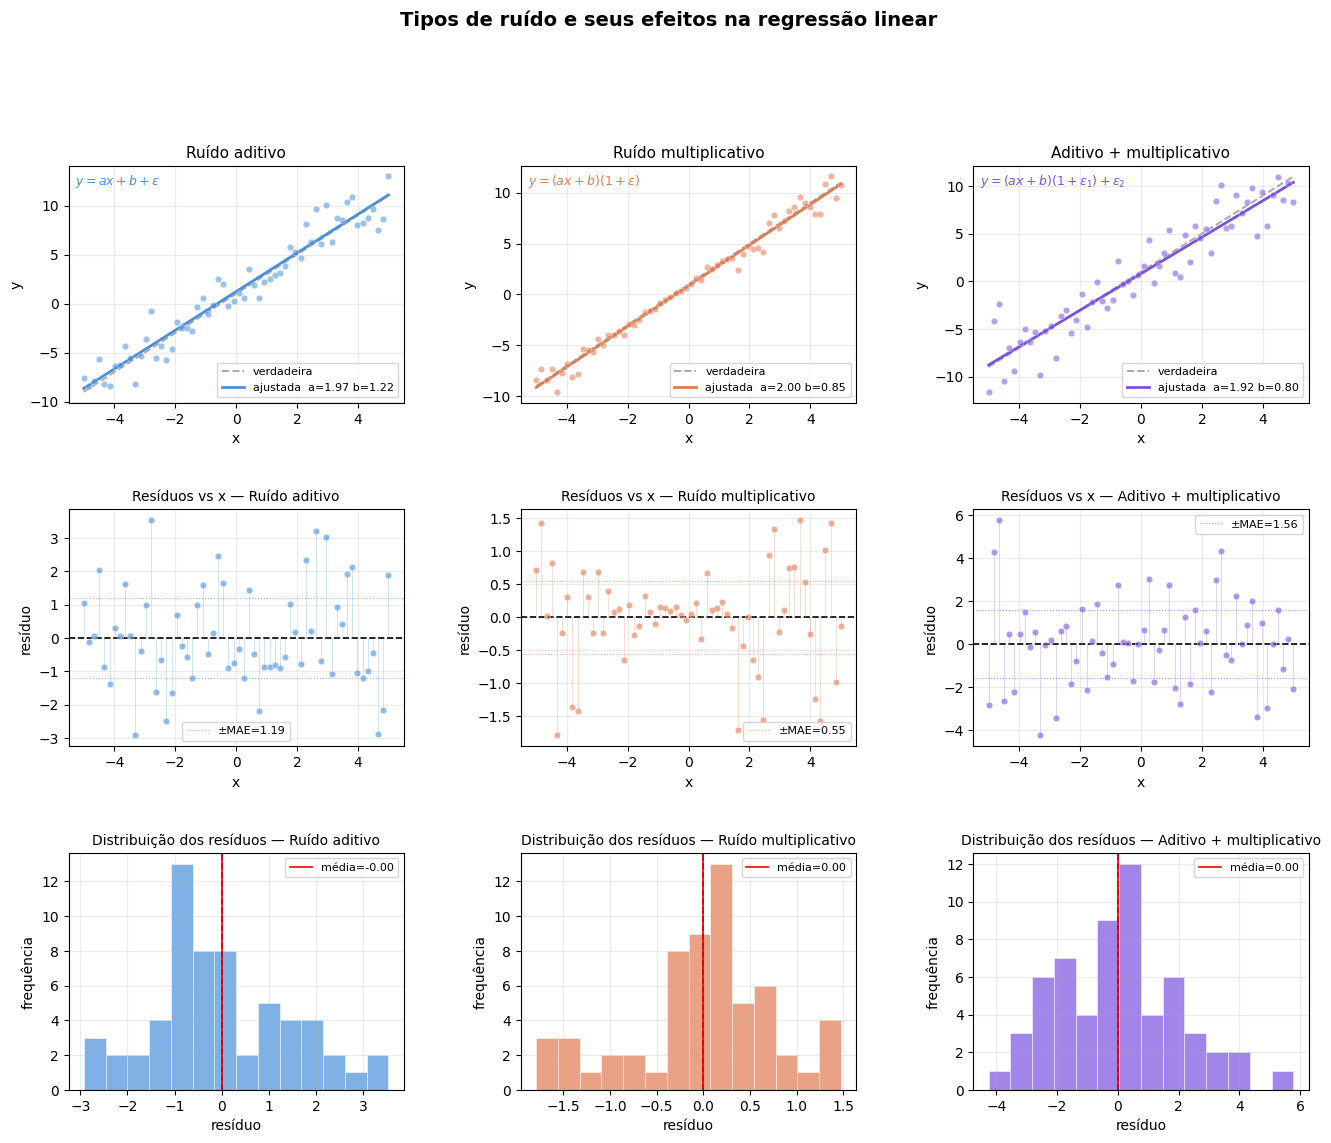

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Semente para reprodutibilidade ────────────────────────────────────────────
rng = __import__('random')
import random
random.seed(42)

# ── Gerador de ruído gaussiano (Box-Muller — sem frameworks) ──────────────────
import math

def ruido_gaussiano(n, media=0.0, sigma=1.0):
    """Gera n amostras de N(media, sigma) usando transformação Box-Muller."""
    amostras = []
    for _ in range(n // 2 + 1):
        u1 = random.random() + 1e-12
        u2 = random.random()
        z0 = math.sqrt(-2 * math.log(u1)) * math.cos(2 * math.pi * u2)
        z1 = math.sqrt(-2 * math.log(u1)) * math.sin(2 * math.pi * u2)
        amostras.extend([media + sigma * z0, media + sigma * z1])
    return amostras[:n]

# ── Parâmetros ────────────────────────────────────────────────────────────────
a, b   = 2.0, 1.0
n      = 60
sigma_add  = 1.5    # desvio padrão do ruído aditivo
sigma_mult = 0.15   # desvio padrão do ruído multiplicativo (15%)

x = [round(-5 + i * (10 / (n - 1)), 4) for i in range(n)]
y_true = [a * xi + b for xi in x]

# ── Gerando os ruídos ─────────────────────────────────────────────────────────
eps_add  = ruido_gaussiano(n, sigma=sigma_add)
eps_mult = ruido_gaussiano(n, sigma=sigma_mult)
eps_add2 = ruido_gaussiano(n, sigma=sigma_add)
eps_mul2 = ruido_gaussiano(n, sigma=sigma_mult)

y_aditivo      = [y_true[i] + eps_add[i]                        for i in range(n)]
y_mult         = [y_true[i] * (1 + eps_mult[i])                 for i in range(n)]
y_ambos        = [y_true[i] * (1 + eps_mul2[i]) + eps_add2[i]   for i in range(n)]

# ── MQO do zero ───────────────────────────────────────────────────────────────
def mqo(x, y):
    n     = len(x)
    xb    = sum(x) / n
    yb    = sum(y) / n
    num   = sum((x[i] - xb) * (y[i] - yb) for i in range(n))
    den   = sum((x[i] - xb) ** 2           for i in range(n))
    a_hat = num / den
    b_hat = yb - a_hat * xb
    return a_hat, b_hat

def r2(x, y, a, b):
    yb     = sum(y) / len(y)
    ss_res = sum((y[i] - (a * x[i] + b)) ** 2 for i in range(len(y)))
    ss_tot = sum((y[i] - yb)             ** 2 for i in range(len(y)))
    return 1 - ss_res / ss_tot

a_add,  b_add  = mqo(x, y_aditivo)
a_mul,  b_mul  = mqo(x, y_mult)
a_amb,  b_amb  = mqo(x, y_ambos)

print("=== Parâmetros verdadeiros:  a=2.0  b=1.0 ===\n")
print(f"Aditivo        → a={a_add:.3f}  b={b_add:.3f}  R²={r2(x, y_aditivo, a_add, b_add):.4f}")
print(f"Multiplicativo → a={a_mul:.3f}  b={b_mul:.3f}  R²={r2(x, y_mult,    a_mul, b_mul):.4f}")
print(f"Ambos          → a={a_amb:.3f}  b={b_amb:.3f}  R²={r2(x, y_ambos,   a_amb, b_amb):.4f}")

# ── Visualização ──────────────────────────────────────────────────────────────
x_line = [round(-5 + i * 0.05, 3) for i in range(201)]

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

cenarios = [
    (y_aditivo, a_add, b_add, 'Ruído aditivo',           '#4a90d9',
     r'$y = ax+b + \epsilon$'),
    (y_mult,    a_mul, b_mul, 'Ruído multiplicativo',     '#e07b52',
     r'$y = (ax+b)(1+\epsilon)$'),
    (y_ambos,   a_amb, b_amb, 'Aditivo + multiplicativo', '#7b52e0',
     r'$y = (ax+b)(1+\epsilon_1)+\epsilon_2$'),
]

for col, (y_obs, a_h, b_h, titulo, cor, formula) in enumerate(cenarios):

    y_fit = [a_h * xi + b_h for xi in x_line]
    resid = [y_obs[i] - (a_h * x[i] + b_h) for i in range(n)]

    # --- linha 1: dados + reta ---
    ax = fig.add_subplot(gs[0, col])
    ax.scatter(x, y_obs, color=cor, alpha=0.55, s=22,
               edgecolors='white', linewidth=0.4, zorder=3)
    ax.plot(x_line, [a * xi + b for xi in x_line],
            color='#aaaaaa', linewidth=1.4, linestyle='--', label='verdadeira')
    ax.plot(x_line, y_fit, color=cor, linewidth=2,
            label=f'ajustada  a={a_h:.2f} b={b_h:.2f}')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('x', fontsize=10); ax.set_ylabel('y', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
    ax.text(0.02, 0.97, formula, transform=ax.transAxes,
            fontsize=9, va='top', color=cor)

    # --- linha 2: resíduos ao longo de x ---
    ax2 = fig.add_subplot(gs[1, col])
    ax2.scatter(x, resid, color=cor, alpha=0.6, s=22,
                edgecolors='white', linewidth=0.4, zorder=3)
    ax2.axhline(0, color='black', linewidth=1.2, linestyle='--')

    # banda ±sigma para referência
    sigma_ref = sum(abs(r) for r in resid) / n
    ax2.axhline( sigma_ref, color=cor, linewidth=0.8,
                 linestyle=':', alpha=0.6, label=f'±MAE={sigma_ref:.2f}')
    ax2.axhline(-sigma_ref, color=cor, linewidth=0.8, linestyle=':', alpha=0.6)

    for xi, ri in zip(x, resid):
        ax2.plot([xi, xi], [0, ri], color=cor, linewidth=0.5, alpha=0.35)

    ax2.set_xlabel('x', fontsize=10)
    ax2.set_ylabel('resíduo', fontsize=10)
    ax2.set_title(f'Resíduos vs x — {titulo}', fontsize=10)
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.25)

    # --- linha 3: histograma dos resíduos ---
    ax3 = fig.add_subplot(gs[2, col])
    ax3.hist(resid, bins=14, color=cor, alpha=0.7,
             edgecolor='white', linewidth=0.5)
    ax3.axvline(0, color='black', linewidth=1.2, linestyle='--')
    media_res = sum(resid) / n
    ax3.axvline(media_res, color='red', linewidth=1.2,
                linestyle='-', label=f'média={media_res:.2f}')
    ax3.set_xlabel('resíduo', fontsize=10)
    ax3.set_ylabel('frequência', fontsize=10)
    ax3.set_title(f'Distribuição dos resíduos — {titulo}', fontsize=10)
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.25)

plt.suptitle('Tipos de ruído e seus efeitos na regressão linear',
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

## Ruído e a média: o que muda?

O erro residual diminui conforme $n$ cresce.

---

### Como o erro da média diminui com $n$?

O desvio padrão da média amostral (erro padrão) é:

$$\sigma_{\bar{y}} = \frac{\sigma}{\sqrt{n}}$$

Ou seja:
- $n = 1$   → erro padrão $= \sigma$
- $n = 10$  → erro padrão $= \sigma / 3{,}16$
- $n = 100$ → erro padrão $= \sigma / 10$
- $n = 10000$ → erro padrão $= \sigma / 100$

**Dobrar a precisão exige quadruplicar o tamanho da amostra.**

---

### Como controlar o ruído?

| Estratégia | Mecanismo | Efeito |
|---|---|---|
| Aumentar $n$ | Mais amostras → $\sigma/\sqrt{n}$ cai | Reduz erro da média |
| Repetir medições e fazer média | Cancela ruído aleatório | Atenua $\sigma$ efetivo |
| Filtrar outliers | Remove perturbações extremas | Reduz viés por ruído assimétrico |
| Reduzir $\sigma$ na fonte | Melhorar o instrumento | Reduz o ruído diretamente |